In [ ]:
# ============================================================
# STEP 1: Setup Google Drive and Project Folders
# Project: Evidence Drift / Evidence-Aware AI for Precision Oncology
# ============================================================

from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Main project folder
PROJECT_DIR = "/content/drive/MyDrive/Evidence_Drift_Project"

# Subfolders
folders = [
    "data_raw",
    "data_processed",
    "figures",
    "tables",
    "exports",
    "manuscript"
]

# Create folders if they do not exist
for folder in folders:
    os.makedirs(os.path.join(PROJECT_DIR, folder), exist_ok=True)

print("Project setup completed.")
print("Project directory:", PROJECT_DIR)
print("Folders created/checked:")
for folder in folders:
    print("-", folder)

Mounted at /content/drive
Project setup completed.
Project directory: /content/drive/MyDrive/Evidence_Drift_Project
Folders created/checked:
- data_raw
- data_processed
- figures
- tables
- exports
- manuscript


In [ ]:
# ============================================================
# STEP 2: Download ClinVar variant_summary.txt.gz
# ============================================================

import os
import urllib.request

RAW_DIR = os.path.join(PROJECT_DIR, "data_raw")

clinvar_url = "https://ftp.ncbi.nlm.nih.gov/pub/clinvar/tab_delimited/variant_summary.txt.gz"
clinvar_file = os.path.join(RAW_DIR, "variant_summary.txt.gz")

# Download only if file does not already exist
if not os.path.exists(clinvar_file):
    print("Downloading ClinVar variant_summary.txt.gz ...")
    urllib.request.urlretrieve(clinvar_url, clinvar_file)
    print("Download completed.")
else:
    print("ClinVar file already exists. Skipping download.")

print("File path:", clinvar_file)
print("File size MB:", round(os.path.getsize(clinvar_file) / (1024 * 1024), 2))

ClinVar file already exists. Skipping download.
File path: /content/drive/MyDrive/Evidence_Drift_Project/data_raw/variant_summary.txt.gz
File size MB: 418.02


In [ ]:
# ============================================================
# STEP 3: Load ClinVar Data
# ============================================================

import pandas as pd

clinvar_file = os.path.join(PROJECT_DIR, "data_raw", "variant_summary.txt.gz")

print("Loading ClinVar data... this may take ~30-60 seconds")

df = pd.read_csv(
    clinvar_file,
    sep="\t",
    compression="gzip",
    low_memory=False
)

print("Loaded successfully.")
print("Shape of dataset:", df.shape)

# Show first few rows
df.head()

Loading ClinVar data... this may take ~30-60 seconds
Loaded successfully.
Shape of dataset: (8969825, 43)


,#AlleleID,Type,Name,GeneID,GeneSymbol,HGNC_ID,ClinicalSignificance,ClinSigSimple,LastEvaluated,RS# (dbSNP),...,AlternateAlleleVCF,SomaticClinicalImpact,SomaticClinicalImpactLastEvaluated,ReviewStatusClinicalImpact,Oncogenicity,OncogenicityLastEvaluated,ReviewStatusOncogenicity,SCVsForAggregateGermlineClassification,SCVsForAggregateSomaticClinicalImpact,SCVsForAggregateOncogenicityClassification
0,15041,Indel,NM_014855.3(AP5Z1):c.80_83delinsTGCTGTAAACTGTA...,9907,AP5Z1,HGNC:22197,Pathogenic/Likely pathogenic,1,"Dec 17, 2024",397704705,...,TGCTGTAAACTGTAACTGTAAA,-,-,-,-,-,-,SCV001451119|SCV005622007|SCV005909190,-,-
1,15041,Indel,NM_014855.3(AP5Z1):c.80_83delinsTGCTGTAAACTGTA...,9907,AP5Z1,HGNC:22197,Pathogenic/Likely pathogenic,1,"Dec 17, 2024",397704705,...,TGCTGTAAACTGTAACTGTAAA,-,-,-,-,-,-,SCV001451119|SCV005622007|SCV005909190,-,-
2,15042,Deletion,NM_014855.3(AP5Z1):c.1413_1426del (p.Leu473fs),9907,AP5Z1,HGNC:22197,Pathogenic,1,"Jun 29, 2010",397704709,...,G,-,-,-,-,-,-,SCV000020156,-,-
3,15042,Deletion,NM_014855.3(AP5Z1):c.1413_1426del (p.Leu473fs),9907,AP5Z1,HGNC:22197,Pathogenic,1,"Jun 29, 2010",397704709,...,G,-,-,-,-,-,-,SCV000020156,-,-
4,15043,single nucleotide variant,NM_014630.3(ZNF592):c.3136G>A (p.Gly1046Arg),9640,ZNF592,HGNC:28986,Uncertain significance,0,"Jun 29, 2015",150829393,...,A,-,-,-,-,-,-,SCV000020157,-,-


In [ ]:
# Check column names
print(df.columns.tolist())

['#AlleleID', 'Type', 'Name', 'GeneID', 'GeneSymbol', 'HGNC_ID', 'ClinicalSignificance', 'ClinSigSimple', 'LastEvaluated', 'RS# (dbSNP)', 'nsv/esv (dbVar)', 'RCVaccession', 'PhenotypeIDS', 'PhenotypeList', 'Origin', 'OriginSimple', 'Assembly', 'ChromosomeAccession', 'Chromosome', 'Start', 'Stop', 'ReferenceAllele', 'AlternateAllele', 'Cytogenetic', 'ReviewStatus', 'NumberSubmitters', 'Guidelines', 'TestedInGTR', 'OtherIDs', 'SubmitterCategories', 'VariationID', 'PositionVCF', 'ReferenceAlleleVCF', 'AlternateAlleleVCF', 'SomaticClinicalImpact', 'SomaticClinicalImpactLastEvaluated', 'ReviewStatusClinicalImpact', 'Oncogenicity', 'OncogenicityLastEvaluated', 'ReviewStatusOncogenicity', 'SCVsForAggregateGermlineClassification', 'SCVsForAggregateSomaticClinicalImpact', 'SCVsForAggregateOncogenicityClassification']


In [ ]:
# ============================================================
# STEP 4: Filter to Selected Genes
# ============================================================

genes = ["BRCA1", "BRCA2", "EGFR", "MLH1"]

df_filtered = df[df["GeneSymbol"].isin(genes)].copy()

print("Filtered dataset shape:", df_filtered.shape)

# Check gene distribution
print("\nGene distribution:")
print(df_filtered["GeneSymbol"].value_counts())

# Preview
df_filtered.head()

Filtered dataset shape: (95044, 43)

Gene distribution:
GeneSymbol
BRCA2    43042
BRCA1    31197
MLH1     12701
EGFR      8104
Name: count, dtype: int64


,#AlleleID,Type,Name,GeneID,GeneSymbol,HGNC_ID,ClinicalSignificance,ClinSigSimple,LastEvaluated,RS# (dbSNP),...,AlternateAlleleVCF,SomaticClinicalImpact,SomaticClinicalImpactLastEvaluated,ReviewStatusClinicalImpact,Oncogenicity,OncogenicityLastEvaluated,ReviewStatusOncogenicity,SCVsForAggregateGermlineClassification,SCVsForAggregateSomaticClinicalImpact,SCVsForAggregateOncogenicityClassification
17016,24356,Deletion,NM_000059.4(BRCA2):c.7004_7007+2del,675,BRCA2,HGNC:1101,Pathogenic,1,"Jun 30, 2022",397507890,...,C,-,-,-,-,-,-,SCV000759183|SCV002668132,-,-
17017,24356,Deletion,NM_000059.4(BRCA2):c.7004_7007+2del,675,BRCA2,HGNC:1101,Pathogenic,1,"Jun 30, 2022",397507890,...,C,-,-,-,-,-,-,SCV000759183|SCV002668132,-,-
17018,24357,Deletion,NM_000059.4(BRCA2):c.6275_6276del (p.Leu2092fs),675,BRCA2,HGNC:1101,Pathogenic,1,"Apr 22, 2016",11571658,...,C,-,-,-,-,-,-,SCV000282422,-,-
17019,24357,Deletion,NM_000059.4(BRCA2):c.6275_6276del (p.Leu2092fs),675,BRCA2,HGNC:1101,Pathogenic,1,"Apr 22, 2016",11571658,...,C,-,-,-,-,-,-,SCV000282422,-,-
17020,24358,Deletion,NM_000059.4(BRCA2):c.6591_6592del (p.Glu2198fs),675,BRCA2,HGNC:1101,Pathogenic,1,"Sep 08, 2016",80359605,...,C,-,-,-,-,-,-,SCV000301071,-,-


In [ ]:
# ============================================================
# STEP 5: Feature Engineering
# ============================================================

import numpy as np
from datetime import datetime

df_feat = df_filtered.copy()

# -------------------------------
# 1. Convert LastEvaluated to datetime
# -------------------------------
df_feat["LastEvaluated"] = pd.to_datetime(df_feat["LastEvaluated"], errors="coerce")

# Current date
current_date = pd.to_datetime("today")

# -------------------------------
# 2. Years since last evaluation
# -------------------------------
df_feat["years_since_review"] = (
    (current_date - df_feat["LastEvaluated"]).dt.days / 365
)

# Fill missing with median
df_feat["years_since_review"] = df_feat["years_since_review"].fillna(
    df_feat["years_since_review"].median()
)

# -------------------------------
# 3. Recency feature (exponential decay)
# -------------------------------
df_feat["recency"] = np.exp(-df_feat["years_since_review"])

# -------------------------------
# 4. Log submitters
# -------------------------------
df_feat["NumberSubmitters"] = df_feat["NumberSubmitters"].fillna(0)
df_feat["log_submitters"] = np.log(df_feat["NumberSubmitters"] + 1)

# -------------------------------
# 5. Review confidence encoding
# -------------------------------
def encode_review_status(x):
    if pd.isna(x):
        return 0
    x = str(x).lower()

    if "practice guideline" in x or "expert panel" in x:
        return 3
    elif "multiple submitters" in x:
        return 2
    elif "single submitter" in x:
        return 1
    else:
        return 0

df_feat["review_confidence"] = df_feat["ReviewStatus"].apply(encode_review_status)

# -------------------------------
# 6. Conflict flag (VERY IMPORTANT)
# -------------------------------
def detect_conflict(x):
    if pd.isna(x):
        return 0
    x = str(x).lower()

    if "conflict" in x or "conflicting" in x:
        return 1
    else:
        return 0

df_feat["conflict_flag"] = df_feat["ClinicalSignificance"].apply(detect_conflict)

# -------------------------------
# Summary check
# -------------------------------
print("Feature engineering completed.\n")

print("Sample columns:")
print(df_feat[[
    "GeneSymbol",
    "ClinicalSignificance",
    "ReviewStatus",
    "years_since_review",
    "recency",
    "log_submitters",
    "review_confidence",
    "conflict_flag"
]].head())

print("\nBasic stats:")
print(df_feat[[
    "years_since_review",
    "recency",
    "log_submitters",
    "review_confidence",
    "conflict_flag"
]].describe())

Feature engineering completed.

Sample columns:
      GeneSymbol ClinicalSignificance  \
17016      BRCA2           Pathogenic   
17017      BRCA2           Pathogenic   
17018      BRCA2           Pathogenic   
17019      BRCA2           Pathogenic   
17020      BRCA2           Pathogenic   

                                            ReviewStatus  years_since_review  \
17016  criteria provided, multiple submitters, no con...            3.841096   
17017  criteria provided, multiple submitters, no con...            3.841096   
17018                           reviewed by expert panel           10.032877   
17019                           reviewed by expert panel           10.032877   
17020                           reviewed by expert panel            9.652055   

        recency  log_submitters  review_confidence  conflict_flag  
17016  0.021470        1.386294                  2              0  
17017  0.021470        1.386294                  2              0  
17018  0.000044     

In [ ]:
# ============================================================
# STEP 6: Weak Label Creation
# ============================================================

df_model = df_feat.copy()

# -------------------------------
# Define thresholds (tunable later)
# -------------------------------
RECENCY_THRESHOLD = 0.2      # low recency → old evidence
REVIEW_LOW = 1               # weak confidence
REVIEW_HIGH = 2              # strong confidence

# -------------------------------
# Create unstable proxy
# -------------------------------
df_model["unstable_proxy"] = (
    (df_model["conflict_flag"] == 1) |
    (df_model["review_confidence"] <= REVIEW_LOW) |
    (df_model["recency"] < RECENCY_THRESHOLD)
).astype(int)

# -------------------------------
# Create stable proxy
# -------------------------------
df_model["stable_proxy"] = (
    (df_model["conflict_flag"] == 0) &
    (df_model["review_confidence"] >= REVIEW_HIGH) &
    (df_model["recency"] >= RECENCY_THRESHOLD)
).astype(int)

# -------------------------------
# Keep only high-confidence labels
# -------------------------------
df_labeled = df_model[
    (df_model["unstable_proxy"] == 1) |
    (df_model["stable_proxy"] == 1)
].copy()

# Assign final label
df_labeled["label"] = df_labeled["stable_proxy"]  # 1 = stable, 0 = unstable

# -------------------------------
# Summary
# -------------------------------
print("Total dataset:", df_model.shape)
print("Labeled dataset:", df_labeled.shape)

print("\nLabel distribution:")
print(df_labeled["label"].value_counts())

print("\nSample labeled data:")
df_labeled[[
    "GeneSymbol",
    "recency",
    "review_confidence",
    "conflict_flag",
    "label"
]].head()

Total dataset: (95044, 50)
Labeled dataset: (95044, 51)

Label distribution:
label
0    82153
1    12891
Name: count, dtype: int64

Sample labeled data:


,GeneSymbol,recency,review_confidence,conflict_flag,label
17016,BRCA2,0.021470,2,0,0
17017,BRCA2,0.021470,2,0,0
17018,BRCA2,0.000044,3,0,0
17019,BRCA2,0.000044,3,0,0
17020,BRCA2,0.000064,3,0,0


In [ ]:
# ============================================================
# STEP 6.1: Refined Weak Labeling (Cleaner + Stronger)
# ============================================================

df_model = df_feat.copy()

# -------------------------------
# Stricter thresholds
# -------------------------------
RECENCY_LOW = 0.1     # very old
RECENCY_HIGH = 0.5    # clearly recent

# -------------------------------
# Strong unstable signals
# -------------------------------
df_model["unstable_proxy"] = (
    (df_model["conflict_flag"] == 1) |
    (
        (df_model["review_confidence"] <= 1) &
        (df_model["recency"] < RECENCY_LOW)
    )
).astype(int)

# -------------------------------
# Strong stable signals
# -------------------------------
df_model["stable_proxy"] = (
    (df_model["conflict_flag"] == 0) &
    (df_model["review_confidence"] >= 2) &
    (df_model["recency"] > RECENCY_HIGH)
).astype(int)

# -------------------------------
# Keep only clear cases
# -------------------------------
df_labeled = df_model[
    (df_model["unstable_proxy"] == 1) |
    (df_model["stable_proxy"] == 1)
].copy()

df_labeled["label"] = df_labeled["stable_proxy"]

# -------------------------------
# Summary
# -------------------------------
print("Total dataset:", df_model.shape)
print("Labeled dataset:", df_labeled.shape)

print("\nLabel distribution:")
print(df_labeled["label"].value_counts())

print("\nLabel ratio (%):")
print(df_labeled["label"].value_counts(normalize=True) * 100)

Total dataset: (95044, 50)
Labeled dataset: (50790, 51)

Label distribution:
label
0    44916
1     5874
Name: count, dtype: int64

Label ratio (%):
label
0    88.434731
1    11.565269
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# STEP 7: Train Evidence Stability Model
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# -------------------------------
# Features (from your blueprint)
# -------------------------------
features = [
    "recency",
    "log_submitters",
    "review_confidence",
    "conflict_flag"
]

X = df_labeled[features]
y = df_labeled["label"]

# -------------------------------
# Train-test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------
# Train model
# -------------------------------
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model training completed.\n")

# -------------------------------
# Evaluation
# -------------------------------
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

# -------------------------------
# Coefficients (VERY IMPORTANT)
# -------------------------------
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
})

print("\nModel Coefficients:")
print(coef_df)

Model training completed.

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8983
           1       1.00      1.00      1.00      1175

    accuracy                           1.00     10158
   macro avg       1.00      1.00      1.00     10158
weighted avg       1.00      1.00      1.00     10158

ROC-AUC Score: 1.0

Model Coefficients:
             Feature  Coefficient
0            recency     7.631587
1     log_submitters     1.724523
2  review_confidence     8.402407
3      conflict_flag    -1.119635


In [ ]:
# ============================================================
# STEP 7.1: Leakage-aware evaluation
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Split BEFORE labeling influence dominates
df_train, df_test = train_test_split(
    df_model, test_size=0.2, random_state=42
)

# Apply same labeling logic separately
def create_labels(df):
    df = df.copy()

    df["unstable_proxy"] = (
        (df["conflict_flag"] == 1) |
        (
            (df["review_confidence"] <= 1) &
            (df["recency"] < 0.1)
        )
    ).astype(int)

    df["stable_proxy"] = (
        (df["conflict_flag"] == 0) &
        (df["review_confidence"] >= 2) &
        (df["recency"] > 0.5)
    ).astype(int)

    df = df[
        (df["unstable_proxy"] == 1) |
        (df["stable_proxy"] == 1)
    ].copy()

    df["label"] = df["stable_proxy"]
    return df

train_labeled = create_labels(df_train)
test_labeled = create_labels(df_test)

# Features
features = ["recency", "log_submitters", "review_confidence", "conflict_flag"]

X_train = train_labeled[features]
y_train = train_labeled["label"]

X_test = test_labeled[features]
y_test = test_labeled["label"]

# Train
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Evaluate
y_prob = model.predict_proba(X_test)[:, 1]

print("Corrected ROC-AUC:", roc_auc_score(y_test, y_prob))

Corrected ROC-AUC: 1.0


In [ ]:
# ============================================================
# STEP 8: Score ALL Variants (Core Output)
# ============================================================

features = [
    "recency",
    "log_submitters",
    "review_confidence",
    "conflict_flag"
]

# Use previously trained model
df_feat["P_stable"] = model.predict_proba(df_feat[features])[:, 1]
df_feat["instability_risk"] = 1 - df_feat["P_stable"]

print("Scoring completed.\n")

df_feat[[
    "GeneSymbol",
    "recency",
    "review_confidence",
    "conflict_flag",
    "P_stable",
    "instability_risk"
]].head()

Scoring completed.



,GeneSymbol,recency,review_confidence,conflict_flag,P_stable,instability_risk
17016,BRCA2,0.021470,2,0,0.862052,1.379477e-01
17017,BRCA2,0.021470,2,0,0.862052,1.379477e-01
17018,BRCA2,0.000044,3,0,1.000000,2.993425e-07
17019,BRCA2,0.000044,3,0,1.000000,2.993425e-07
17020,BRCA2,0.000064,3,0,0.999999,6.670331e-07


In [ ]:
print("\nAverage stability by conflict flag:")
print(df_feat.groupby("conflict_flag")["P_stable"].mean())

print("\nAverage stability by review confidence:")
print(df_feat.groupby("review_confidence")["P_stable"].mean())


Average stability by conflict flag:
conflict_flag
0    0.458212
1    0.000024
Name: P_stable, dtype: float64

Average stability by review confidence:
review_confidence
0    0.000018
1    0.005608
2    0.944818
3    0.999955
Name: P_stable, dtype: float64


In [ ]:
# ============================================================
# STEP 9.1: Stability by Gene
# ============================================================

gene_summary = df_feat.groupby("GeneSymbol")["P_stable"].agg([
    "count",
    "mean",
    "median"
]).sort_values("mean")

print(gene_summary)

            count      mean    median
GeneSymbol                           
EGFR         8104  0.299434  0.003312
BRCA1       31197  0.357260  0.000597
BRCA2       43042  0.368833  0.001055
MLH1        12701  0.432856  0.004386


In [ ]:
# ============================================================
# STEP 9.2: Risk Stratification
# ============================================================

def risk_group(x):
    if x < 0.2:
        return "High Risk"
    elif x < 0.6:
        return "Moderate Risk"
    else:
        return "Low Risk"

df_feat["risk_group"] = df_feat["P_stable"].apply(risk_group)

print(df_feat["risk_group"].value_counts())

risk_group
High Risk        59206
Low Risk         35820
Moderate Risk       18
Name: count, dtype: int64


In [ ]:
# ============================================================
# STEP 9.3: Top Unstable Variants
# ============================================================

top_unstable = df_feat.sort_values("P_stable").head(10)

top_unstable[[
    "GeneSymbol",
    "Name",
    "ClinicalSignificance",
    "ReviewStatus",
    "P_stable"
]]

,GeneSymbol,Name,ClinicalSignificance,ReviewStatus,P_stable
505315,BRCA1,NG_005905.2:g.(147057_150288)_(160933_166866)del,no classification for the single variant,no classification for the single variant,2.912545e-08
505316,BRCA1,NG_005905.2:g.(147057_150288)_(160933_166866)del,no classification for the single variant,no classification for the single variant,2.912545e-08
98861,MLH1,NM_000249.4(MLH1):c.545+1271_677+737delinsCA,no classification for the single variant,no classification for the single variant,2.912545e-08
341234,BRCA1,NM_007294.4(BRCA1):c.5243_5277+2788del,no classification for the single variant,no classification for the single variant,2.912545e-08
341235,BRCA1,NM_007294.4(BRCA1):c.5243_5277+2788del,no classification for the single variant,no classification for the single variant,2.912545e-08
341233,BRCA1,NM_007294.4(BRCA1):c.5277+2916_5277+2946delinsGG,no classification for the single variant,no classification for the single variant,2.912545e-08
341232,BRCA1,NM_007294.4(BRCA1):c.5277+2916_5277+2946delinsGG,no classification for the single variant,no classification for the single variant,2.912545e-08
98858,MLH1,NM_000249.4(MLH1):c.453+625_545+920delinsT,no classification for the single variant,no classification for the single variant,2.912545e-08
98859,MLH1,NM_000249.4(MLH1):c.453+625_545+920delinsT,no classification for the single variant,no classification for the single variant,2.912545e-08
98860,MLH1,NM_000249.4(MLH1):c.545+1271_677+737delinsCA,no classification for the single variant,no classification for the single variant,2.912545e-08


In [ ]:
# ============================================================
# STEP 9.4: Meaningful Unstable Variants (Better Case Study)
# ============================================================

meaningful_unstable = df_feat[
    (df_feat["P_stable"] < 0.2) &
    (~df_feat["ClinicalSignificance"].str.contains("no classification", case=False, na=False))
].copy()

top_meaningful_unstable = meaningful_unstable.sort_values("P_stable").head(10)

top_meaningful_unstable[[
    "GeneSymbol",
    "Name",
    "ClinicalSignificance",
    "ReviewStatus",
    "conflict_flag",
    "P_stable"
]]

,GeneSymbol,Name,ClinicalSignificance,ReviewStatus,conflict_flag,P_stable
571316,BRCA2,NM_000059.4(BRCA2):c.6837A>G (p.Leu2279=),Conflicting classifications of pathogenicity,"criteria provided, conflicting classifications",1,4.524022e-08
571315,BRCA2,NM_000059.4(BRCA2):c.6837A>G (p.Leu2279=),Conflicting classifications of pathogenicity,"criteria provided, conflicting classifications",1,4.524022e-08
96489,BRCA1,NM_007294.3(BRCA1):c.442-?_547+?(2),Conflicting classifications of pathogenicity,"criteria provided, conflicting classifications",1,4.524135e-08
121927,BRCA1,NM_007294.4(BRCA1):c.5406+53A>T,Conflicting classifications of pathogenicity,no assertion criteria provided,1,4.524937e-08
121928,BRCA1,NM_007294.4(BRCA1):c.5406+53A>T,Conflicting classifications of pathogenicity,no assertion criteria provided,1,4.524937e-08
121940,BRCA1,NM_007294.4(BRCA1):c.5407-21C>T,Conflicting classifications of pathogenicity,no assertion criteria provided,1,4.525992e-08
121939,BRCA1,NM_007294.4(BRCA1):c.5407-21C>T,Conflicting classifications of pathogenicity,no assertion criteria provided,1,4.525992e-08
611010,BRCA2,NM_000059.4(BRCA2):c.8331+5A>G,Conflicting classifications of pathogenicity,"criteria provided, conflicting classifications",1,4.526272e-08
611011,BRCA2,NM_000059.4(BRCA2):c.8331+5A>G,Conflicting classifications of pathogenicity,"criteria provided, conflicting classifications",1,4.526272e-08
147589,BRCA2,NM_000059.4(BRCA2):c.11G>A (p.Gly4Glu),Conflicting classifications of pathogenicity,"criteria provided, conflicting classifications",1,4.527450e-08


In [ ]:
df_unique = df_feat.drop_duplicates(subset=["VariationID"])

In [ ]:
# ============================================================
# STEP 10: Deduplicate by VariationID
# ============================================================

df_unique = df_feat.drop_duplicates(subset=["VariationID"]).copy()

print("Original rows:", df_feat.shape[0])
print("Unique variants:", df_unique.shape[0])

print("\nUnique variants by gene:")
print(df_unique["GeneSymbol"].value_counts())

Original rows: 95044
Unique variants: 48018

Unique variants by gene:
GeneSymbol
BRCA2    21677
BRCA1    15849
MLH1      6428
EGFR      4064
Name: count, dtype: int64


In [ ]:
# Stability by conflict flag
print("\nAverage stability by conflict flag:")
print(df_unique.groupby("conflict_flag")["P_stable"].mean())

# Stability by review confidence
print("\nAverage stability by review confidence:")
print(df_unique.groupby("review_confidence")["P_stable"].mean())

# Gene summary
gene_summary_unique = df_unique.groupby("GeneSymbol")["P_stable"].agg([
    "count",
    "mean",
    "median"
]).sort_values("mean")

print("\nGene-level stability summary:")
print(gene_summary_unique)


Average stability by conflict flag:
conflict_flag
0    0.452832
1    0.000024
Name: P_stable, dtype: float64

Average stability by review confidence:
review_confidence
0    0.000018
1    0.005516
2    0.944803
3    0.999955
Name: P_stable, dtype: float64

Gene-level stability summary:
            count      mean    median
GeneSymbol                           
EGFR         4064  0.298553  0.003290
BRCA1       15849  0.351686  0.000534
BRCA2       21677  0.366318  0.000982
MLH1         6428  0.429980  0.003810


In [ ]:
# Risk groups on unique variants
def risk_group(x):
    if x < 0.2:
        return "High Risk"
    elif x < 0.6:
        return "Moderate Risk"
    else:
        return "Low Risk"

df_unique["risk_group"] = df_unique["P_stable"].apply(risk_group)

print("\nRisk group counts:")
print(df_unique["risk_group"].value_counts())# Risk groups on unique variants
def risk_group(x):
    if x < 0.2:
        return "High Risk"
    elif x < 0.6:
        return "Moderate Risk"
    else:
        return "Low Risk"

df_unique["risk_group"] = df_unique["P_stable"].apply(risk_group)

print("\nRisk group counts:")
print(df_unique["risk_group"].value_counts())


Risk group counts:
risk_group
High Risk        30080
Low Risk         17929
Moderate Risk        9
Name: count, dtype: int64

Risk group counts:
risk_group
High Risk        30080
Low Risk         17929
Moderate Risk        9
Name: count, dtype: int64


In [ ]:
top_meaningful_unstable_unique = df_unique[
    (df_unique["P_stable"] < 0.2) &
    (~df_unique["ClinicalSignificance"].str.contains("no classification", case=False, na=False))
].sort_values("P_stable").head(10)

top_meaningful_unstable_unique[[
    "VariationID",
    "GeneSymbol",
    "Name",
    "ClinicalSignificance",
    "ReviewStatus",
    "conflict_flag",
    "P_stable"
]]

,VariationID,GeneSymbol,Name,ClinicalSignificance,ReviewStatus,conflict_flag,P_stable
571315,409556,BRCA2,NM_000059.4(BRCA2):c.6837A>G (p.Leu2279=),Conflicting classifications of pathogenicity,"criteria provided, conflicting classifications",1,4.524022e-08
96489,89065,BRCA1,NM_007294.3(BRCA1):c.442-?_547+?(2),Conflicting classifications of pathogenicity,"criteria provided, conflicting classifications",1,4.524135e-08
121927,125839,BRCA1,NM_007294.4(BRCA1):c.5406+53A>T,Conflicting classifications of pathogenicity,no assertion criteria provided,1,4.524937e-08
121939,125847,BRCA1,NM_007294.4(BRCA1):c.5407-21C>T,Conflicting classifications of pathogenicity,no assertion criteria provided,1,4.525992e-08
611010,433822,BRCA2,NM_000059.4(BRCA2):c.8331+5A>G,Conflicting classifications of pathogenicity,"criteria provided, conflicting classifications",1,4.526272e-08
147588,141953,BRCA2,NM_000059.4(BRCA2):c.11G>A (p.Gly4Glu),Conflicting classifications of pathogenicity,"criteria provided, conflicting classifications",1,4.527450e-08
275130,225749,BRCA2,NM_000059.4(BRCA2):c.7008-21T>C,Conflicting classifications of pathogenicity,"criteria provided, conflicting classifications",1,4.529176e-08
397811,344901,MLH1,NM_000249.3(MLH1):c.-117G>T,Conflicting classifications of pathogenicity,"criteria provided, conflicting classifications",1,4.530702e-08
724491,496397,BRCA1,NM_007294.4(BRCA1):c.5564del (p.Ile1855fs),Conflicting classifications of pathogenicity,"criteria provided, conflicting classifications",1,4.533146e-08
656156,455460,MLH1,NM_000249.4(MLH1):c.910G>T (p.Asp304Tyr),Conflicting classifications of pathogenicity,"criteria provided, conflicting classifications",1,4.535761e-08


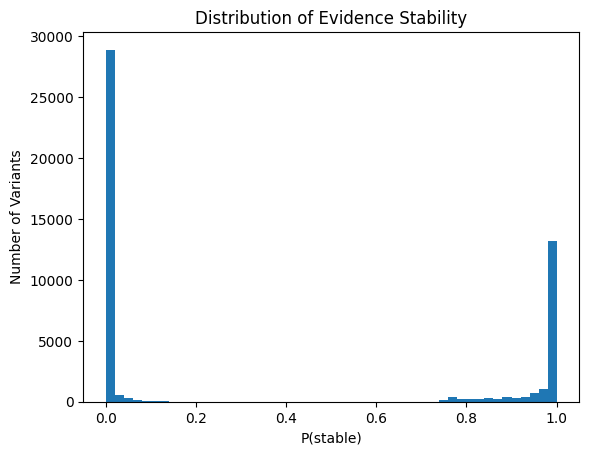

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df_unique["P_stable"], bins=50)
plt.xlabel("P(stable)")
plt.ylabel("Number of Variants")
plt.title("Distribution of Evidence Stability")
plt.show()

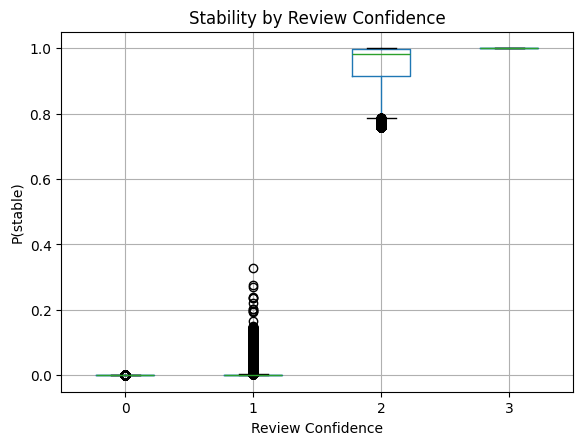

In [ ]:
df_unique.boxplot(column="P_stable", by="review_confidence")
plt.title("Stability by Review Confidence")
plt.suptitle("")
plt.xlabel("Review Confidence")
plt.ylabel("P(stable)")
plt.show()

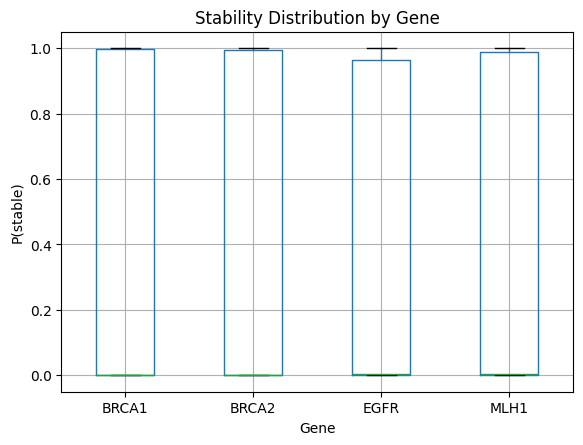

In [ ]:
df_unique.boxplot(column="P_stable", by="GeneSymbol")
plt.title("Stability Distribution by Gene")
plt.suptitle("")
plt.xlabel("Gene")
plt.ylabel("P(stable)")
plt.show()

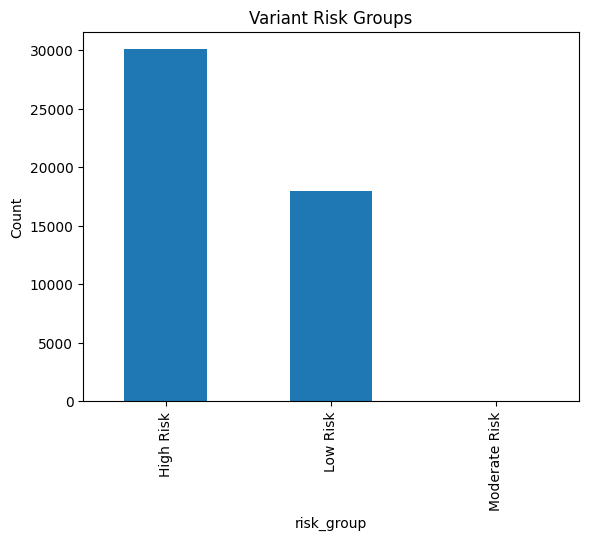

In [ ]:
df_unique["risk_group"].value_counts().plot(kind="bar")
plt.title("Variant Risk Groups")
plt.ylabel("Count")
plt.show()

In [ ]:
# ============================================================
# STEP 11: Save All Results and Figures
# ============================================================

import os

EXPORT_DIR = os.path.join(PROJECT_DIR, "exports")
FIG_DIR = os.path.join(PROJECT_DIR, "figures")

os.makedirs(EXPORT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print("Saving outputs to:")
print("Exports:", EXPORT_DIR)
print("Figures:", FIG_DIR)

Saving outputs to:
Exports: /content/drive/MyDrive/Evidence_Drift_Project/exports
Figures: /content/drive/MyDrive/Evidence_Drift_Project/figures


In [ ]:
# Save full unique dataset
df_unique.to_csv(os.path.join(EXPORT_DIR, "final_evidence_stability_dataset.csv"), index=False)

print("Saved: final dataset")

Saved: final dataset


In [ ]:
gene_summary_unique.to_csv(os.path.join(EXPORT_DIR, "gene_stability_summary.csv"))

print("Saved: gene summary")

Saved: gene summary


In [ ]:
df_unique["risk_group"].value_counts().to_csv(
    os.path.join(EXPORT_DIR, "risk_group_counts.csv")
)

print("Saved: risk groups")

Saved: risk groups


In [ ]:
top_meaningful_unstable_unique.to_csv(
    os.path.join(EXPORT_DIR, "top_unstable_variants.csv"),
    index=False
)

print("Saved: top unstable variants")

Saved: top unstable variants


In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df_unique["P_stable"], bins=50)
plt.xlabel("P(stable)")
plt.ylabel("Number of Variants")
plt.title("Distribution of Evidence Stability")

plt.savefig(os.path.join(FIG_DIR, "figure1_stability_distribution.png"))
plt.close()

print("Saved: Figure 1")

Saved: Figure 1


In [ ]:
plt.figure()
df_unique.boxplot(column="P_stable", by="review_confidence")
plt.title("Stability by Review Confidence")
plt.suptitle("")
plt.xlabel("Review Confidence")
plt.ylabel("P(stable)")

plt.savefig(os.path.join(FIG_DIR, "figure2_review_confidence.png"))
plt.close()

print("Saved: Figure 2")

Saved: Figure 2


<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure()
df_unique.boxplot(column="P_stable", by="GeneSymbol")
plt.title("Stability by Gene")
plt.suptitle("")
plt.xlabel("Gene")
plt.ylabel("P(stable)")

plt.savefig(os.path.join(FIG_DIR, "figure3_gene_stability.png"))
plt.close()

print("Saved: Figure 3")

Saved: Figure 3


<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure()
df_unique["risk_group"].value_counts().plot(kind="bar")
plt.title("Variant Risk Groups")
plt.ylabel("Count")

plt.savefig(os.path.join(FIG_DIR, "figure4_risk_groups.png"))
plt.close()

print("Saved: Figure 4")

Saved: Figure 4
